Training Dynamics
   
(a)Did your models show signs of overfitting or underfitting? What architectural or training changes could address this?

The first is the f1 curve of MLP and the second is that of LSTM. From the training and validation curves, the MLP shows mild overfitting and unstable validation behavior. The training metrics keep improving, while validation improves only slightly and fluctuates. The LSTM shows clear overfitting: training F1 approaches 1.0, while validation macro-F1 stays much lower and saturates early.

The possible changes might address are dropout and weight decay. We could also reduce model capacity and use better learning rate strategy.

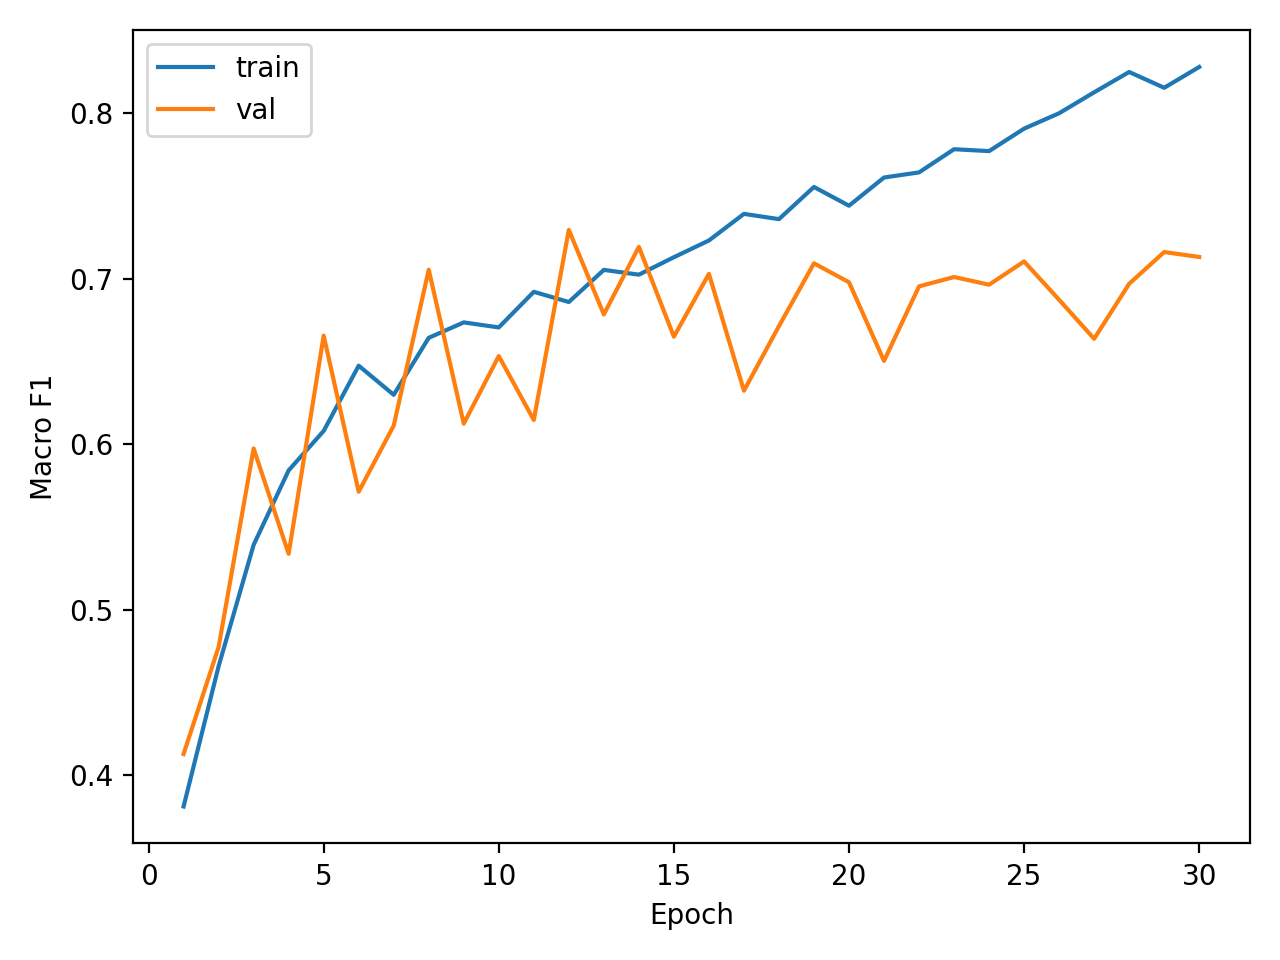
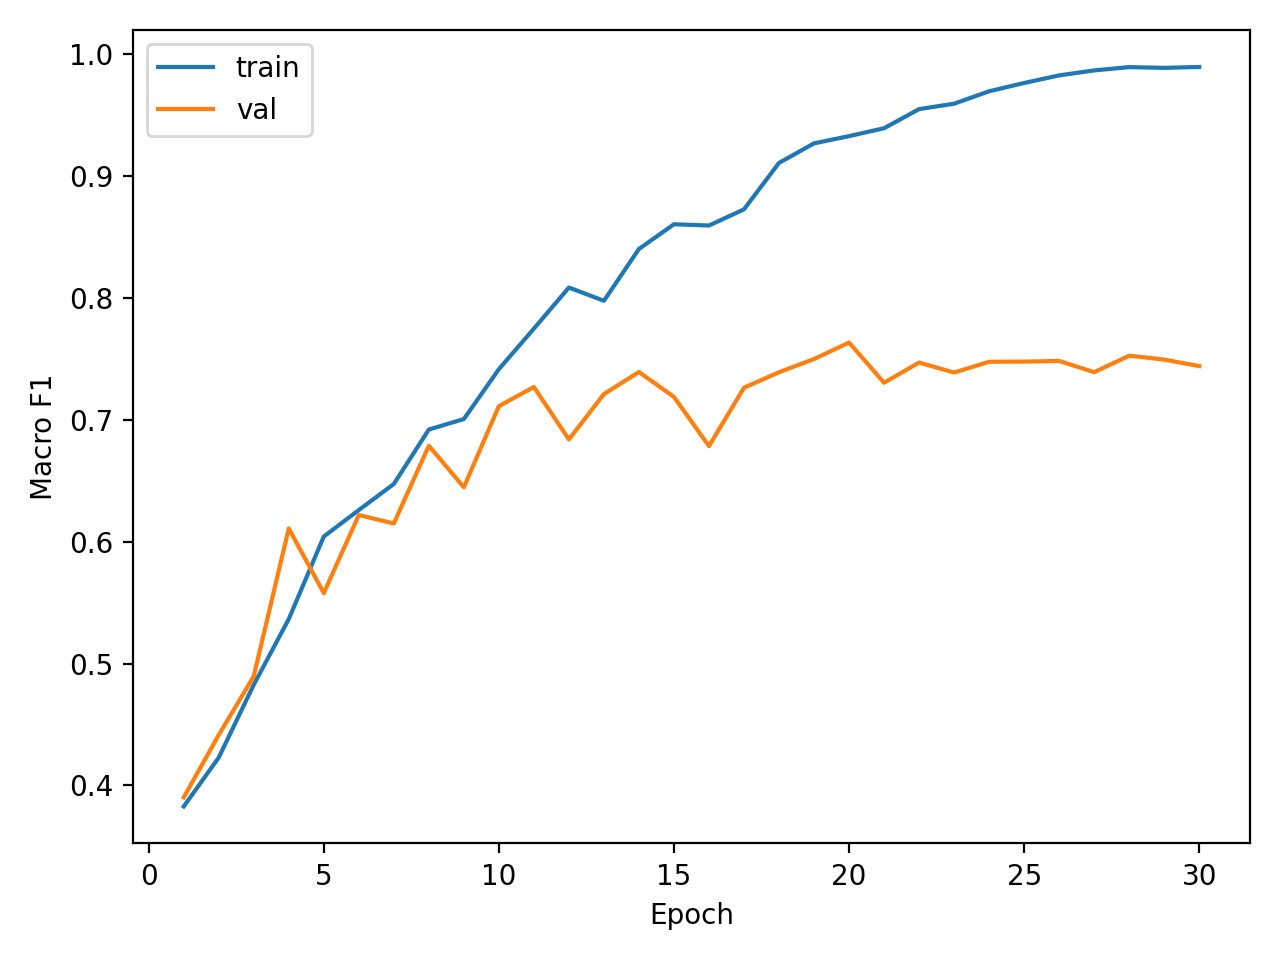

(b) How did using class weights affect training stability and final performance?

Class weights focus on the minor classes and let them contribute more to the gradients. This prevent the model from increasing accuracy too much by predicting the majority class(neutral). So class weights would improve macro-F1, which treats all classes equally. But as minority samples have less samples, each occurrence would cause larger updates. So the macro-F1 would have largers fluctuations.

 Model Performance and Error Analysis
 
(a)Which of your two models generalized better to the test set? Provide evidence from your metrics.

The first one is the confusion matrix of MLP and second is that of LSTM. 

LSTM generalized better. MLP: Test Macro-F1 ≈ 0.704, Test Accuracy ≈ 0.741. LSTM: Test Macro-F1 ≈ 0.767, Test Accuracy ≈ 0.788. Since macro-F1 is the primary metric under class imbalance, the LSTM’s higher macro-F1 indicates stronger generalization.

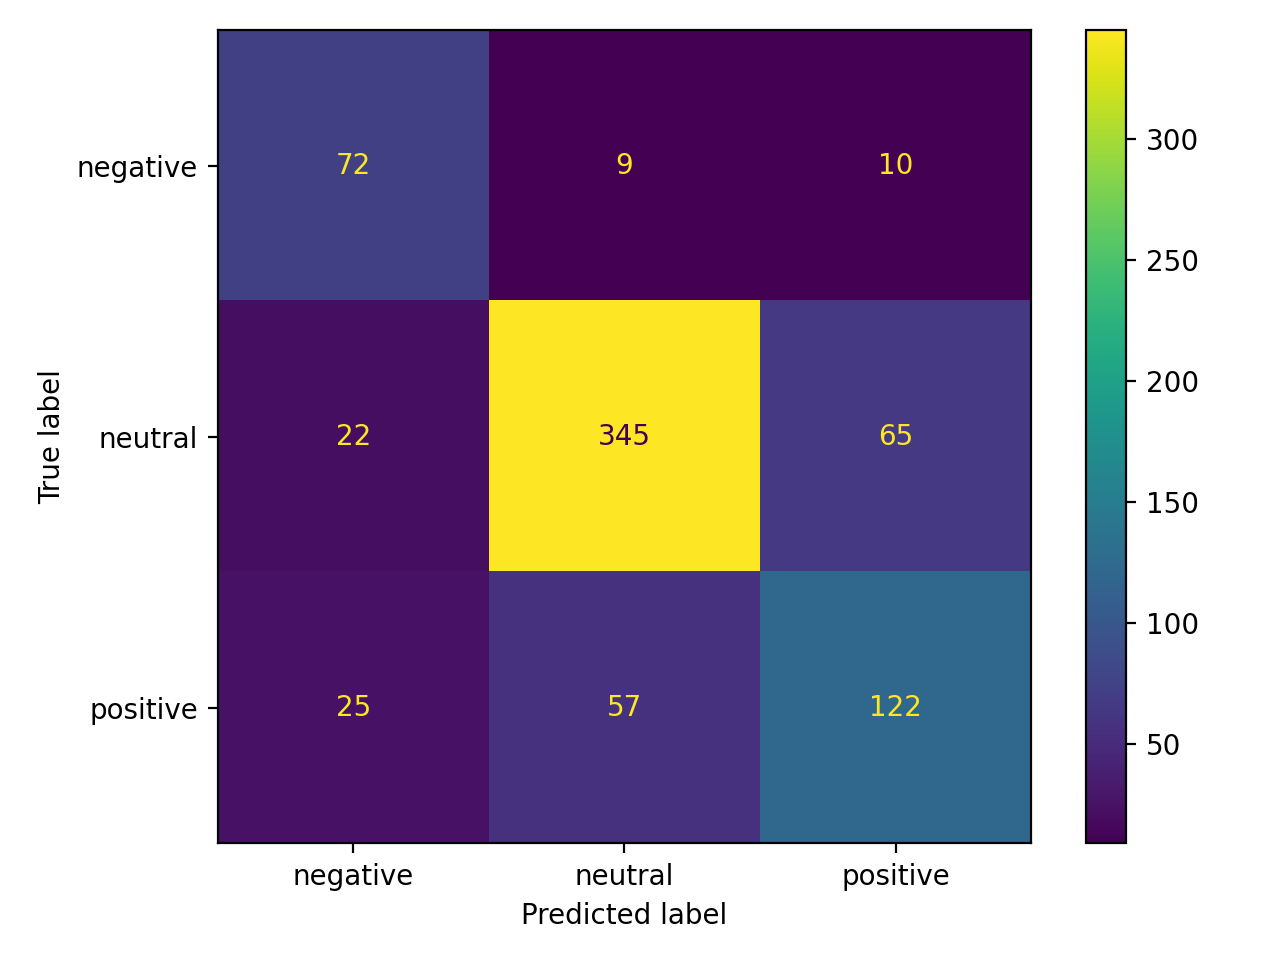
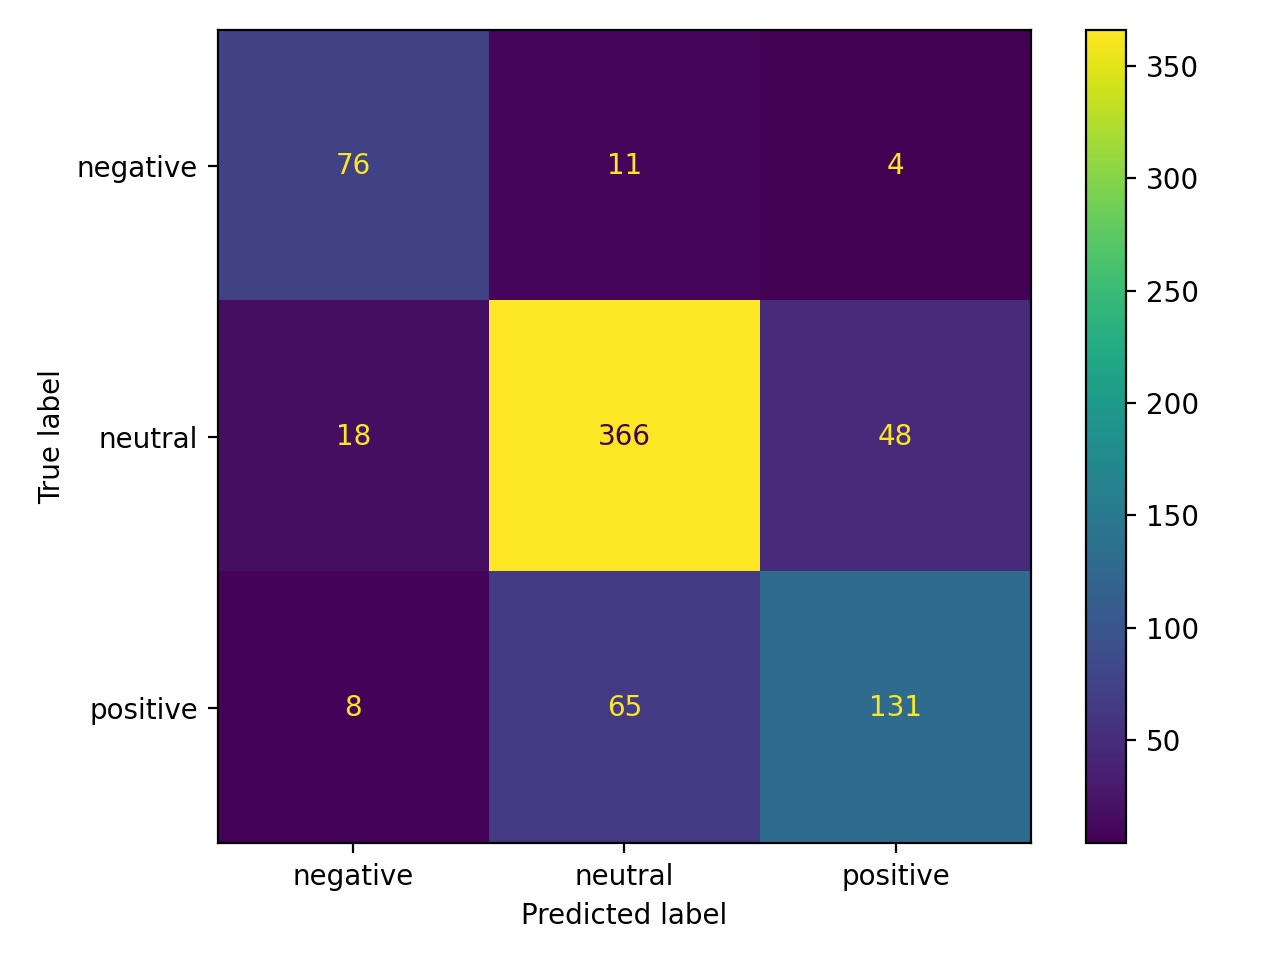

(b) Which sentiment class was most frequently misclassified? Why?

The most frequently misclassified patterns are between neutral and positive. In some contexts, mild positivity is close to neutral, and many words' meanings depend on context. Besides, imbalance among classes would also push borderline cases to the majority class. For MLP, the mean pooling would lose the order and further the confusion.

Cross-Model Comparison

(a) How did mean-pooled FastText embeddings limit the MLP compared to sequence-based models?

Mean pooling is not sensitive to the order of words. It will weaken the compositional cues like negation. Besides, FastText is static embeddings in which words have the same vectors in different context. As a result, MLP performance is hindered by representation loss, even if the classifier is trained well.

(b)What advantage did the LSTM’s sequential processing provide over the MLP?

LSTM captures word order and compositional structure via gated recurrence, making it easier to capture the negation and longer dependencies. The final hidden state acts as a learned sentence representation that reflects sequential reading. This improves minority-class discrimination and macro-F1 compared with MLP.

(c)Did fine-tuned LLMs (BERT/GPT) outperform classical baselines? Explain the performance gap in terms of pretraining and contextual representations.

The first figure is from BERT and the second is from GPT. 

Yes, BERT clearly outperformed classical baselines, while GPT was close to the strongest classical sequence model (LSTM) in this run. The data are as follows: BERT ≈ 0.790 (best), GPT ≈ 0.767, LSTM ≈ 0.767. The gap is mainly from pretraining and contextual representation. BERT/GPT produce context-dependent token embeddings and the pretraining would let the model learn the semantics ahead. And BERT’s bidirectional encoding is especially well-suited for sentence classification.

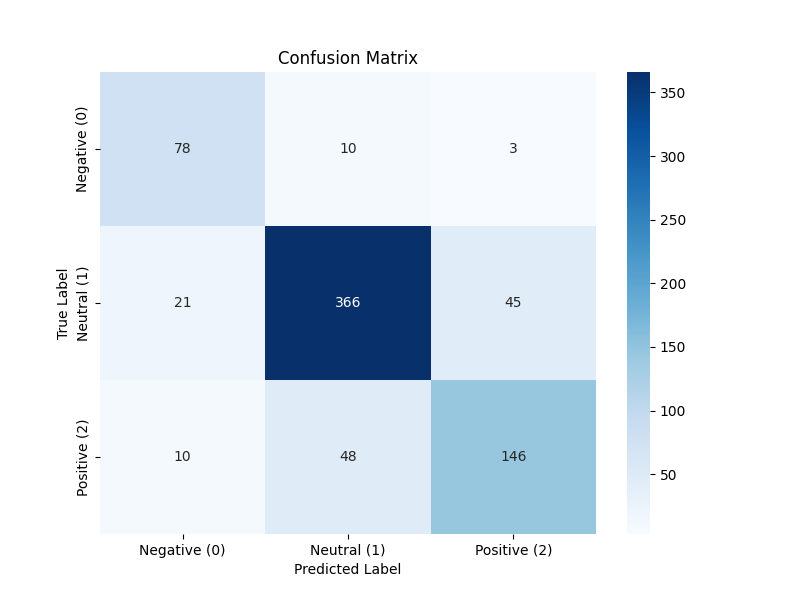
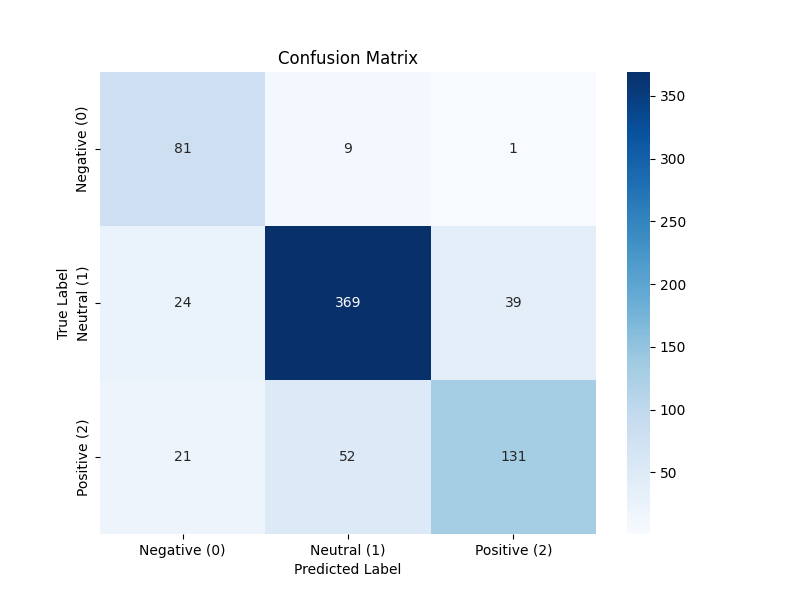

(d)Rank all six models by test performance. What architectural or representational factors explain the ranking?

I will rank the models by test Macro-F1.

BERT (≈ 0.790)
LSTM (≈ 0.767)
GPT (≈ 0.767)
GRU (≈ 0.749)
MLP (≈ 0.704)
RNN (≈ 0.688)

Explanation: BERT benefits most from bidirectional contextual encoding and pretraining. GPT benefits from pretraining but decoder-only structure and classification setup can limit gains versus BERT. Among classical sequence models, gating (LSTM/GRU) improves over vanilla RNN by mitigating vanishing gradients. MLP is limited by order-invariant mean-pooled static embeddings.

## AI Use Disclosure (Required)

If you used any AI-enabled tools (e.g., ChatGPT, GitHub Copilot, Claude, or other LLM assistants) while working on this assignment, you must disclose that use here. The goal is transparency-not punishment.

In your disclosure, briefly include:
- **Tool(s) used:** (name + version if known)
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text)
- **What you verified yourself:** (e.g., reran the notebook, checked outputs/plots, checked shapes, read documentation)
- **What you did *not* use AI for (if applicable):** (optional)

You are responsible for the correctness of your submission, even if AI suggested code or explanations.

#### <font color="red">Write your disclosure here.</font>

I used GPT 5.2. I used it for drafting the code. I checked the outputs and the plots.
